<font size="3">**Tarea 3**</font>

<u> *Instrucciones* </u>

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a *juancaros@udec.cl* el dia 6/6 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. Utilizar la base de datos junaeb3.csv, el diccionario de datos es el siguiente:

- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: siempre - 5: nunca)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

Preguntas:

1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import stepmix
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image



%matplotlib inline

In [2]:
df = pd.read_csv("../data/junaeb3.csv")

# Revisar tipos de datos
print(df.info())

# Revisar valores faltantes
print(df.isnull().sum())


# Estadísticas descriptivas
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31055 entries, 0 to 31054
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        31055 non-null  int64  
 1   edad        31055 non-null  int64  
 2   imce        31055 non-null  float64
 3   vive_padre  31055 non-null  int64  
 4   vive_madre  31055 non-null  int64  
 5   sk1         31055 non-null  int64  
 6   sk2         31055 non-null  int64  
 7   sk3         31055 non-null  int64  
 8   sk4         31055 non-null  int64  
 9   sk5         31055 non-null  int64  
 10  sk6         31055 non-null  int64  
 11  sk7         31055 non-null  int64  
 12  sk8         31055 non-null  int64  
 13  sk9         31055 non-null  int64  
 14  sk10        31055 non-null  int64  
 15  sk11        31055 non-null  int64  
 16  sk12        31055 non-null  int64  
 17  sk13        31055 non-null  int64  
 18  act_fisica  30051 non-null  float64
 19  area        31055 non-nul

In [3]:
# Mostrar solo las variables con valores nulos y su porcentaje
nulos = df.isnull().mean() * 100
print(nulos[nulos > 0])

act_fisica    3.232974
educm         1.201095
dtype: float64


Como son % muy pequeños y solo esas dos variables tienen datos nulos podemos elegir eliminarlos con .dropna()

In [4]:
# Eliminar filas con cualquier valor nulo
df = df.dropna()
print(df.isnull().sum())  # Verifica que ya no hay nulos

sexo          0
edad          0
imce          0
vive_padre    0
vive_madre    0
sk1           0
sk2           0
sk3           0
sk4           0
sk5           0
sk6           0
sk7           0
sk8           0
sk9           0
sk10          0
sk11          0
sk12          0
sk13          0
act_fisica    0
area          0
educm         0
educp         0
madre_work    0
dtype: int64


<Axes: >

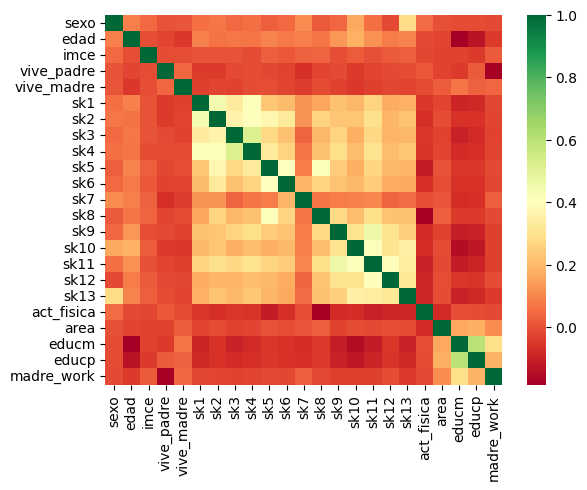

In [5]:
#Creamos un mapa de calor heatmap para visualizar la correlación entre las variables
sns.heatmap(df.corr(), cmap='RdYlGn')

In [6]:
# Estadísticas descriptivas de sk7 ya que es diferente a las demás
print("Valores únicos de sk7:", df['sk7'].unique())
print("\nConteo de cada valor en sk7:")
print(df['sk7'].value_counts())
print("\nEstadísticas descriptivas de sk7:")
print(df['sk7'].describe())

Valores únicos de sk7: [4 2 3 1 5]

Conteo de cada valor en sk7:
sk7
1    10634
2     8039
3     6708
4     2236
5     2079
Name: count, dtype: int64

Estadísticas descriptivas de sk7:
count    29696.000000
mean         2.228415
std          1.209599
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: sk7, dtype: float64


In [7]:
# Se puede observar que sk7 no tiene sentido porque diría que la mayoría de los estudiantes son agresivos, lo cual no tiene lógica, asi que
# se invertirán sus valores y escala de sk7: 1<->5, 2<->4, 3<->3
df2 = df.copy()
df2['sk7'] = 6 - df2['sk7']

# Verifica el cambio
print("Valores únicos de sk7 en df2:", df2['sk7'].unique())
print(df2['sk7'].value_counts())

Valores únicos de sk7 en df2: [2 4 3 5 1]
sk7
5    10634
4     8039
3     6708
2     2236
1     2079
Name: count, dtype: int64


<Axes: >

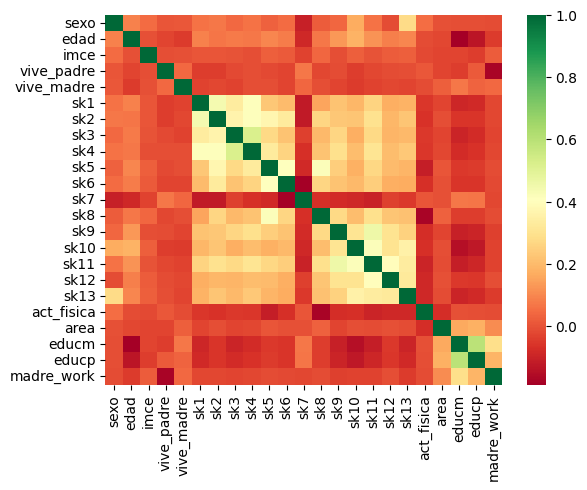

In [8]:
#Volvemos a crear el mapa de calor heatmap para visualizar la correlación entre las variables
sns.heatmap(df2.corr(), cmap='RdYlGn')

In [9]:
#Seleccionamos solo las variables desde sk1 a sk13 para analizar mas profundamente su correlación

df_sk = df2[["sk1", "sk2", "sk3", "sk4", "sk5", "sk6", "sk7", "sk8", "sk9", "sk10", "sk11", "sk12", "sk13"]]

# Matriz de correlaciones entre las variables.
print("Matriz de correlaciones entre sk1-sk13:")
print(df_sk.corr().round(2))


Matriz de correlaciones entre sk1-sk13:
       sk1   sk2   sk3   sk4   sk5   sk6   sk7   sk8   sk9  sk10  sk11  sk12  \
sk1   1.00  0.44  0.33  0.41  0.23  0.20 -0.12  0.16  0.22  0.19  0.26  0.17   
sk2   0.44  1.00  0.36  0.41  0.37  0.33 -0.12  0.26  0.23  0.22  0.30  0.19   
sk3   0.33  0.36  1.00  0.52  0.28  0.22 -0.04  0.20  0.26  0.17  0.27  0.19   
sk4   0.41  0.41  0.52  1.00  0.33  0.26 -0.07  0.22  0.29  0.21  0.30  0.21   
sk5   0.23  0.37  0.28  0.33  1.00  0.41 -0.08  0.42  0.24  0.17  0.27  0.20   
sk6   0.20  0.33  0.22  0.26  0.41  1.00 -0.19  0.26  0.22  0.20  0.25  0.17   
sk7  -0.12 -0.12 -0.04 -0.07 -0.08 -0.19  1.00 -0.07 -0.08 -0.09 -0.10 -0.04   
sk8   0.16  0.26  0.20  0.22  0.42  0.26 -0.07  1.00  0.27  0.21  0.29  0.22   
sk9   0.22  0.23  0.26  0.29  0.24  0.22 -0.08  0.27  1.00  0.31  0.46  0.30   
sk10  0.19  0.22  0.17  0.21  0.17  0.20 -0.09  0.21  0.31  1.00  0.42  0.30   
sk11  0.26  0.30  0.27  0.30  0.27  0.25 -0.10  0.29  0.46  0.42  1.00  0.40   


<u> *Matriz de correlación de "sk_"* </u>

<font size="2"> **Podemos observar después del ajuste que hay varias correlaciones moderadas  (entre 0.2 y 0.5), especialmente entre pares como sk1-sk2, sk3-sk4, sk5-sk8, sk9-sk11, sk10-sk11, etc. sk7 tiene correlaciones bajas o negativas con las demás ya que es la inversa de agresividad.**</font>


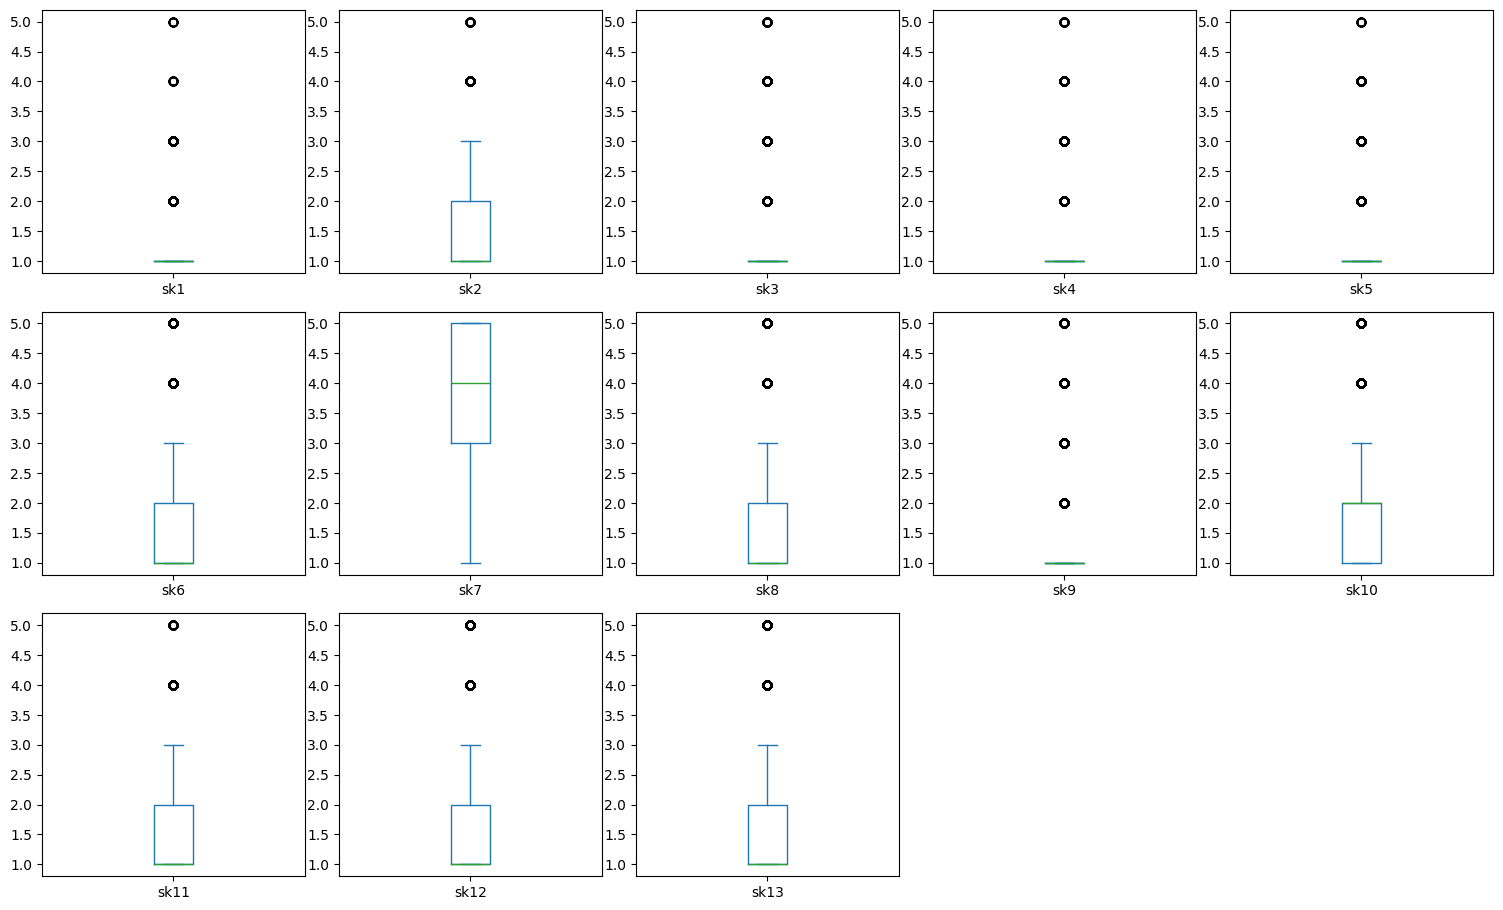

In [10]:
# Boxplot de todas las variables numéricas para detectar outliers
df_sk.plot(kind='box', subplots=True, layout=(5,5), figsize=(15,15))
plt.tight_layout()
plt.show()

<font size="2">**Las variables desde sk1 a sk13, es lógico que estén cerca del 1 y tengan menos valores en los demás, ya que en sí, 1 es bueno y 5 es malo. Menos en  la sk7 que la invertimos.**</font> 

2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

In [11]:
#Usamos factor_analyzer para determinar el número óptimo de factores usamos rotation promax para permitir que los factores estén relacionados.	
#Usamos promax ya que es más adecuado para variables donde los factores pueden estar correlacionados.

fa = FactorAnalyzer(rotation='promax').fit(df_sk)
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
# Veremos las cargas factoriales de cada variable en cada factor identificado por el EFA
fa.loadings_


c:\Users\darmo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([[0.024180, 0.593565, -0.033238],
       [-0.031936, 0.484816, 0.244135],
       [0.019373, 0.647544, -0.037848],
       [0.003449, 0.757164, -0.032839],
       [-0.140561, -0.012967, 0.841413],
       [-0.011133, 0.045899, 0.528580],
       [-0.019643, -0.025673, -0.148558],
       [0.150371, -0.111533, 0.523333],
       [0.494241, 0.071142, 0.054604],
       [0.614228, -0.023963, -0.031593],
       [0.703844, 0.032608, 0.005729],
       [0.573326, -0.036091, -0.000418],
       [0.511997, 0.031292, -0.015209]])

<u> *Explicación cargas factoriales* </u>

<font size="3">Esta es la matriz de cargas de cargas factoriales del EFA, que indica que la cantidad óptima de factores son 3. Cada fila representa una variable y cada número indica cuanda **"carga"** se asocia a ese factor. </font>

<font size="3">Por lo que para agrupar las variables debemos ver para cada columna cuál es el valor más alto. Cabe recalcar que el sk7 no está asociado a ningún factor, esto porque es la "agresividad" de forma invertida para que tuviera sentido entro de la escala de todas las variables, de igual forma según el mapa de correlación, tampoco estaba tan correlacionada a las demás sk. A continuación mostraré en una tabla los factores y sus variables asociadas.</font>

<small>

| Factor     | Variables asociadas                  |
|------------|--------------------------------------|
| Factor 1   | sk9, sk10, sk11, sk12, sk13          |
| Factor 2   | sk1, sk2, sk3, sk4                   |
| Factor 3   | sk5, sk6, sk8                        |

</small>

<font size="3">Ahora usaremos "fa.get_eigenvalues()" que representa la cantidad de varianza total de las variables originales que son explicadas por cada factor extraido del análisis factorial. Según el ciretrio de Kaise se recomienda conservar solo los factores con eigvalue mayores a 1.</font>



In [12]:
# Usamos  get_eigenvalues para obtener los valores propios de la matriz de correlación,
# Para determinar el número óptimo de factores.
fa.get_eigenvalues()

(array([4.034140, 1.350905, 1.114858, 1.001343, 0.791246, 0.707033,
        0.701430, 0.690630, 0.608183, 0.529379, 0.517172, 0.491397,
        0.462285]),
 array([3.440055, 0.754289, 0.589299, 0.212724, 0.095681, 0.058077,
        0.030242, 0.018558, -0.024719, -0.075878, -0.097613, -0.118430,
        -0.174512]))

<font size="3">Según Kaiser, el número óptimo de factores debería ser 4, pero según la matriz de cargas factoriales anterior, debería ser 3, así que probaremos primero con 4 factores y luego con 3 factores y veremos las diferencias</font>

In [13]:
# Obtención de comunalidades
sk_vars = [f'sk{i}' for i in range(1, 14)]
comunalidades = fa.get_communalities()
com_df = pd.DataFrame({'Variable': sk_vars, 'Comunalidad': comunalidades})
print(com_df)
print(com_df[com_df['Comunalidad'] < 0.3])

   Variable  Comunalidad
0       sk1     0.354009
1       sk2     0.295669
2       sk3     0.421122
3       sk4     0.574387
4       sk5     0.727901
5       sk6     0.281628
6       sk7     0.023114
7       sk8     0.308929
8       sk9     0.252317
9      sk10     0.378848
10     sk11     0.496492
11     sk12     0.330005
12     sk13     0.263351
   Variable  Comunalidad
1       sk2     0.295669
5       sk6     0.281628
6       sk7     0.023114
8       sk9     0.252317
12     sk13     0.263351


<u> *Explicación comunalidades* </u>

<font size="3">Se entrega las comunalidades de cada variable, osea, la proporción de cada una que es explicada con los factores extraidos en el modelo. Esto arrojó que la variable sk2, sk6, sk7, sk9 y sk13 no están bien explicadas por los factores extraídos en el EFA, osea que están bajo 0.3.</font>


In [14]:
# Obtener la varianza explicada por cada factor
factor_varianza = fa.get_factor_variance()
print("Suma de varianzas explicadas por cada factor:", factor_varianza[0])
print("Proporción de varianza explicada por cada factor:", factor_varianza[1])
print("Proporción acumulada de varianza explicada:", factor_varianza[2])

Suma de varianzas explicadas por cada factor: [1.752660 1.604332 1.350782]
Proporción de varianza explicada por cada factor: [0.134820 0.123410 0.103906]
Proporción acumulada de varianza explicada: [0.134820 0.258230 0.362136]


<u> *Significado factor_variance()* </u>

- El primer factor explica una varianza de **1.75 (13.5% de la varianza total).**
- El segundo factor explica **1.60 (12.3%).**
- El tercer factor explica **1.35 (10.4%).**
- La varianza acumulada explicada por los **tres factores es 36.2%.**

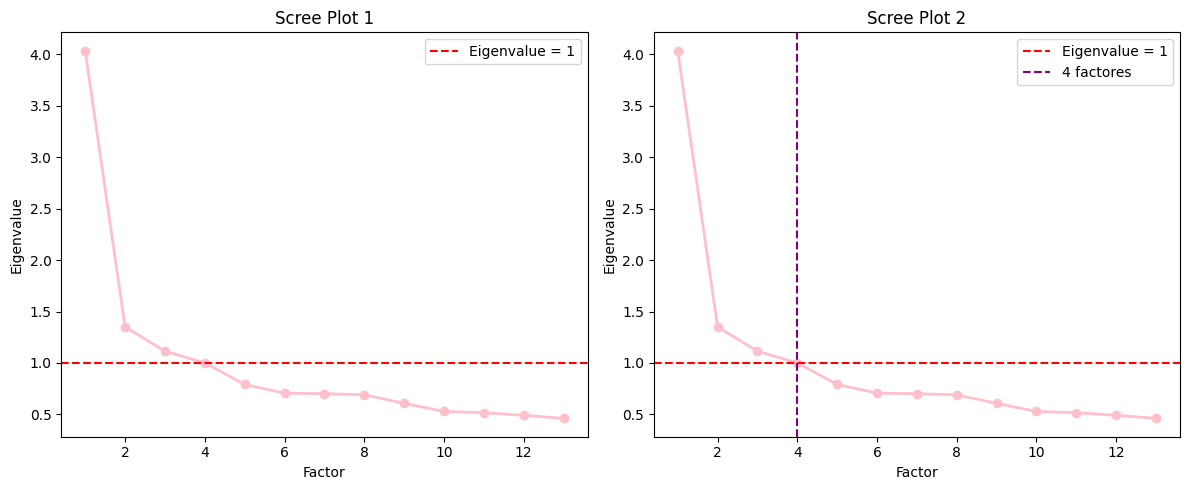

In [15]:
# Hacemos un Scree Plot para visualizar los valores propios de los factores

values = np.arange(1, 14)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.figure(figsize=(12,5))

# Gráfico 1
plt.subplot(1, 2, 1)
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='pink')
plt.title('Scree Plot 1')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.axhline(1, color='red', linestyle='--', label='Eigenvalue = 1')
plt.legend()

# Gráfico 2
plt.subplot(1, 2, 2)
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='pink')
plt.title('Scree Plot 2')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.axhline(1, color='red', linestyle='--', label='Eigenvalue = 1')
plt.axvline(4, color='purple', linestyle='--', label='4 factores')
plt.legend()

plt.tight_layout()
plt.show()

<u> *Explicación de gráficos y obtención de cantidad de factores óptimo* </u>

<font size="3"> Para determinar el número óptimo de factores, se utilizó el **criterio de Kaiser (autovalores mayores a 1)** y la inspección visual del **scree plot**. En el gráfico se observa un “codo” claro en el cuarto factor, a partir del cual la pendiente de los autovalores se aplana. Además, solo los primeros cuatro factores presentan autovalores superiores a 1, lo que indica que explican una proporción relevante de la varianza total.</font> 

<font size="3"> Por lo tanto, se seleccionaron 4 factores. Ahora veremos que variables están en cada factor viendo las cargas factoriales del EFA ajustado con 4 factores. Se considera que una variable está asociada a un factor si su carga absoluta es mayor a 0.4 en ese factor.</font> 

In [16]:
# Ajustar el EFA con 4 factores y mostrar las cargas factoriales
fa4 = FactorAnalyzer(n_factors=4, rotation='promax')
fa4.fit(df_sk)

sk_vars = [f'sk{i}' for i in range(1, 14)]
loadings = pd.DataFrame(fa4.loadings_, index=sk_vars, columns=['Factor 1', 'Factor 2', 'Factor 3', 'Factor 4'])
print("Cargas factoriales (factor loadings):")
print(loadings.round(2))

# Variables asociadas a cada factor según cargas factoriales
factor_dict = {}

for i in range(4):
    factor_name = f'Factor {i+1}'
    variables = loadings[loadings.iloc[:,i].abs() >= 0.39].index.tolist()
    factor_dict[factor_name] = variables

factor_table = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in factor_dict.items()]))
print("Variables asociadas a cada factor:")
display(factor_table)

Cargas factoriales (factor loadings):
      Factor 1  Factor 2  Factor 3  Factor 4
sk1       0.02      0.53     -0.15      0.27
sk2      -0.04      0.42      0.11      0.30
sk3       0.03      0.71      0.04     -0.19
sk4       0.02      0.78      0.03     -0.13
sk5      -0.13      0.05      0.84     -0.01
sk6      -0.00      0.01      0.40      0.25
sk7      -0.01      0.06     -0.01     -0.33
sk8       0.17     -0.05      0.50     -0.04
sk9       0.50      0.10      0.08     -0.07
sk10      0.61     -0.06     -0.09      0.13
sk11      0.70      0.03      0.00      0.02
sk12      0.57     -0.02      0.02     -0.05
sk13      0.51      0.03     -0.02      0.02
Variables asociadas a cada factor:


c:\Users\darmo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor 1,Factor 2,Factor 3,Factor 4
0,sk9,sk1,sk5,NaN
1,sk10,sk2,sk6,NaN
2,sk11,sk3,sk8,NaN
3,sk12,sk4,NaN,NaN
4,sk13,NaN,NaN,NaN


<font size="3">Al realizar el EFA se utilizó el criterio de Kaiser **(autovalores mayores a 1)** y el scree plot para determinar el número óptimo de factores. Según estos métodos, inicialmente se sugirió extraer 4 factores, ya que los primeros cuatro autovalores eran mayores a 1 y el scree plot mostraba un **“codo”** en el cuarto factor.</font>

<font size="3">Sin embargo, al ajustar el modelo con 4 factores y revisar las cargas factoriales, se observó que el cuarto factor no tenía ninguna variable asociada con una carga significativa (por ejemplo, mayor a 0.4). Esto indica que el cuarto factor no aporta información relevante ni agrupa variables de manera interpretable. **Por esta razón, se decidió ajustar el EFA a 3 factores**.</font>



In [17]:
# Ajustar el EFA con 3 factores y mostrar las cargas factoriales
fa3 = FactorAnalyzer(n_factors=3, rotation='promax')
fa3.fit(df_sk)

sk_vars = [f'sk{i}' for i in range(1, 14)]
loadings2 = pd.DataFrame(fa3.loadings_, index=sk_vars, columns=['Factor 1', 'Factor 2', 'Factor 3'])
print("Cargas factoriales (factor loadings):")
print(loadings2.round(2))

# Variables asociadas a cada factor según cargas factoriales
factor_dict2 = {}

for i in range(3):
    factor_name2 = f'Factor {i+1}'
    variables2 = loadings2[loadings2.iloc[:,i].abs() >= 0.4].index.tolist()
    factor_dict2[factor_name2] = variables2

factor_table2 = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in factor_dict2.items()]))
print("Variables asociadas a cada factor:")
display(factor_table2)

Cargas factoriales (factor loadings):
      Factor 1  Factor 2  Factor 3
sk1       0.02      0.59     -0.03
sk2      -0.03      0.48      0.24
sk3       0.02      0.65     -0.04
sk4       0.00      0.76     -0.03
sk5      -0.14     -0.01      0.84
sk6      -0.01      0.05      0.53
sk7      -0.02     -0.03     -0.15
sk8       0.15     -0.11      0.52
sk9       0.49      0.07      0.05
sk10      0.61     -0.02     -0.03
sk11      0.70      0.03      0.01
sk12      0.57     -0.04     -0.00
sk13      0.51      0.03     -0.02
Variables asociadas a cada factor:


c:\Users\darmo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor 1,Factor 2,Factor 3
0,sk9,sk1,sk5
1,sk10,sk2,sk6
2,sk11,sk3,sk8
3,sk12,sk4,NaN
4,sk13,NaN,NaN


Finalmente, es correcto decir que luego de realizar el análisis EFA, el número óptimo de factores son 3, y sk7 no tiene carga factorial suficientemente alta en ninguno de los factores por lo que no se incluyó.

3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

c:\Users\darmo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


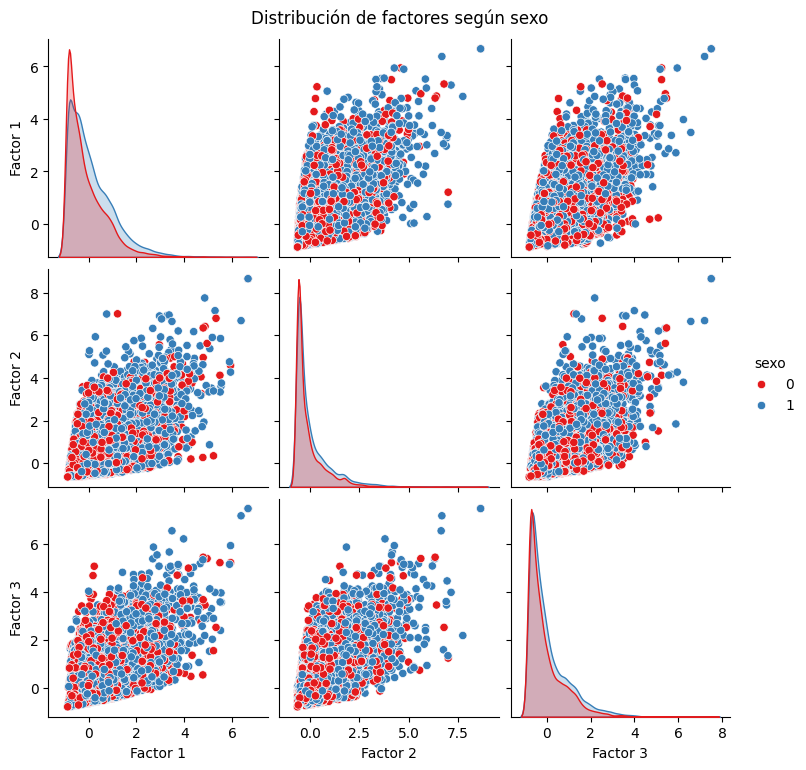

In [18]:
# Obtener los scores de los factores
factor_scores = fa3.transform(df_sk)
df_factores = pd.DataFrame(factor_scores, columns=['Factor 1', 'Factor 2', 'Factor 3'])
df_factores = pd.concat([df_factores, df2[['sexo', 'area', 'imce', 'act_fisica']].reset_index(drop=True)], axis=1)

# Graficar pares de factores coloreando por sexo
sns.pairplot(df_factores, vars=['Factor 1', 'Factor 2', 'Factor 3'], hue='sexo', palette='Set1')
plt.suptitle('Distribución de factores según sexo', y=1.02)
plt.show()



<u> *Explicación distribución de factores según su sexo* </u>

<small>

| Género    | Valor  |
|-----------|--------|
| Femenino  | 1      |
| Masculino | 0      |

</small>

<font size="3">Cada punto es un estudiante coloreado por sexo: 1 si es mujer y 0 si es hombre. Se puede observar que para cada factor no hay una separación clara entre los puntos rojos y azules. Y las distribuciones de los factores en los graficos diagonales son similares para cada sexo. Y en los scatterplots los puntos no forman agrupamientos evidentes, están mezclados. Por lo tanto, tanto hombres como mujeres presentan distribuciones similares en los tres factores extraídos, lo que sugiere que el sexo no influye de manera relevante en la estructura factorial encontrada en este análisis.</font> 

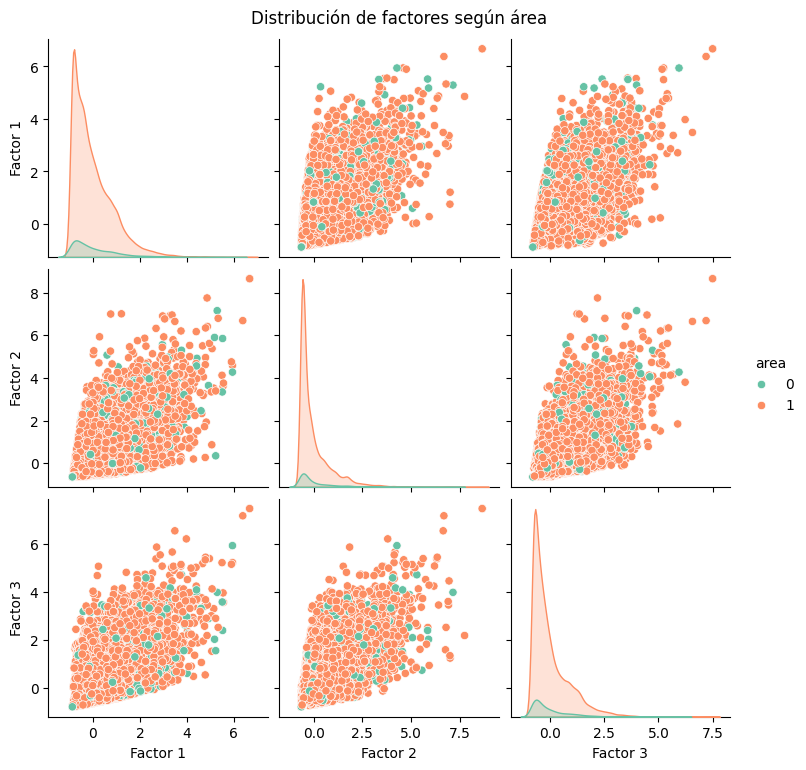

In [19]:
# Graficar pares de factores coloreando por area
sns.pairplot(df_factores, vars=['Factor 1', 'Factor 2', 'Factor 3'], hue='area', palette='Set2')
plt.suptitle('Distribución de factores según área', y=1.02)
plt.show()



<u> *Explicación distribución de factores según área donde vive* </u>

<small>

| Color     | área ()         |
|-----------|-----------------|
| Naranja   | área urbana (1) |
| Verde     | área rural (0)  |

</small>

<font size="3">Se puede observar que la mayoría de los estudiantes eran de áreas urbanas por el color naranja predominante, por lo que la comparación visual puede influir por el tamaño desigual de los datos. Sin embargo, a pesar de la diferencia de cantidad, la distribución de los factores es similar para ambos grupos, es decir, están mezclados y no hay agrupamientos claros. </font>

<font size="3">Así, tanto estudiantes de área urbana como rural presentan distribuciones similares en los tres factores extraídos, lo que sugiere que el área no influye de manera relevante en la estructura factorial encontrada en este análisis.</font>


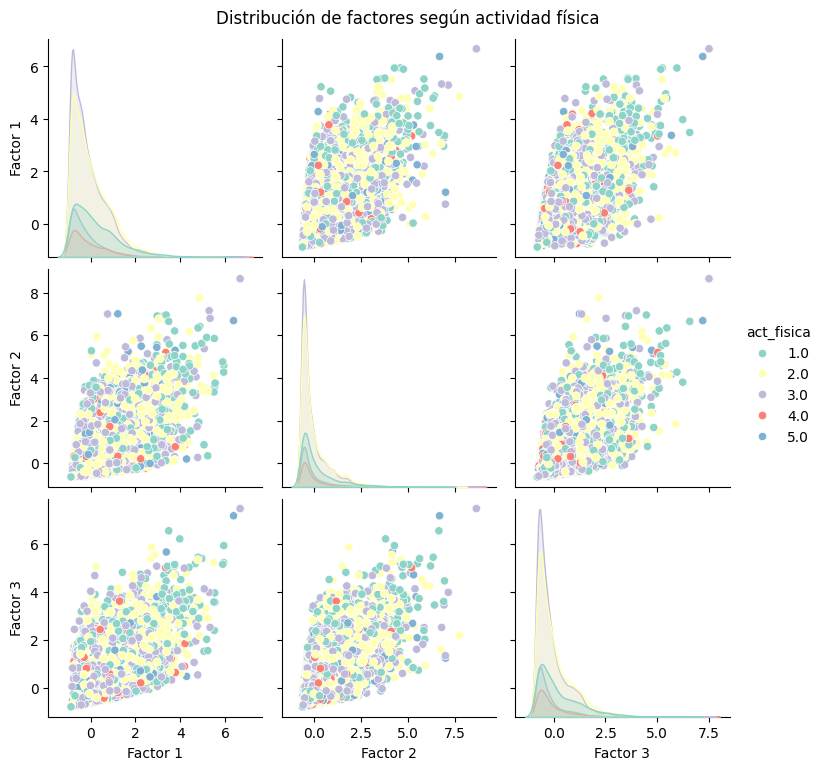

In [20]:
# Graficar pares de factores coloreando por act_fisica 
sns.pairplot(df_factores, vars=['Factor 1', 'Factor 2', 'Factor 3'], hue='act_fisica', palette='Set3')
plt.suptitle('Distribución de factores según actividad física', y=1.02)
plt.show()

<u> *Explicación distribución de factores según nivel de actividad física* </u>

<font size="3">No se observan diferencias significativas en la distribución de los factores según la frecuencia de actividad física de los estudiantes. Esto también puede ser confuso por la cantidad de datos. Todos los grupos de actividad física presentan patrones similares en los factores extraídos, lo que sugiere que la actividad física no influye de manera relevante en la estructura factorial encontrada en este análisis.</font>



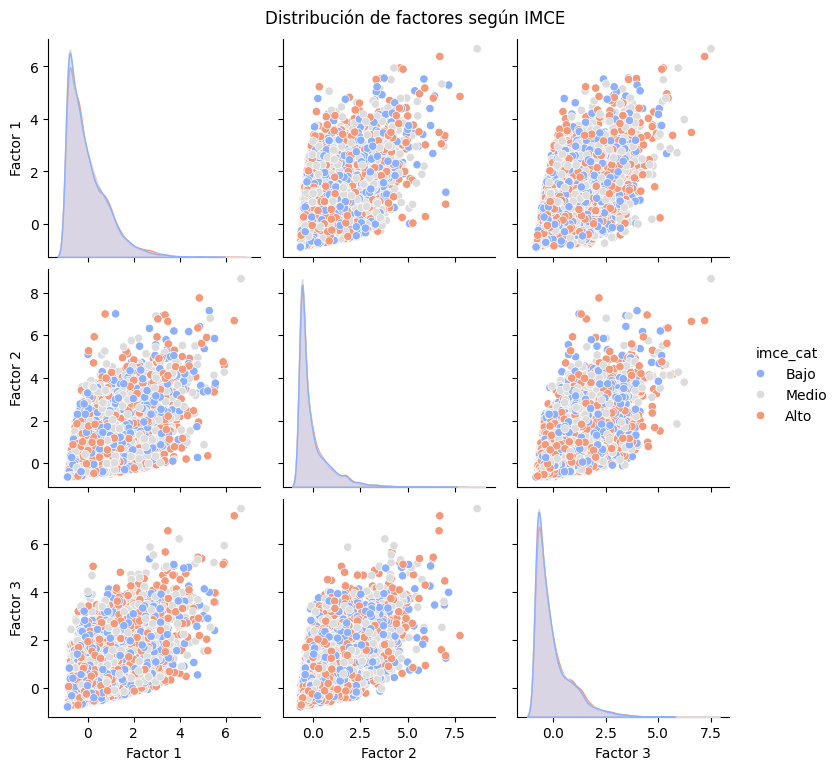

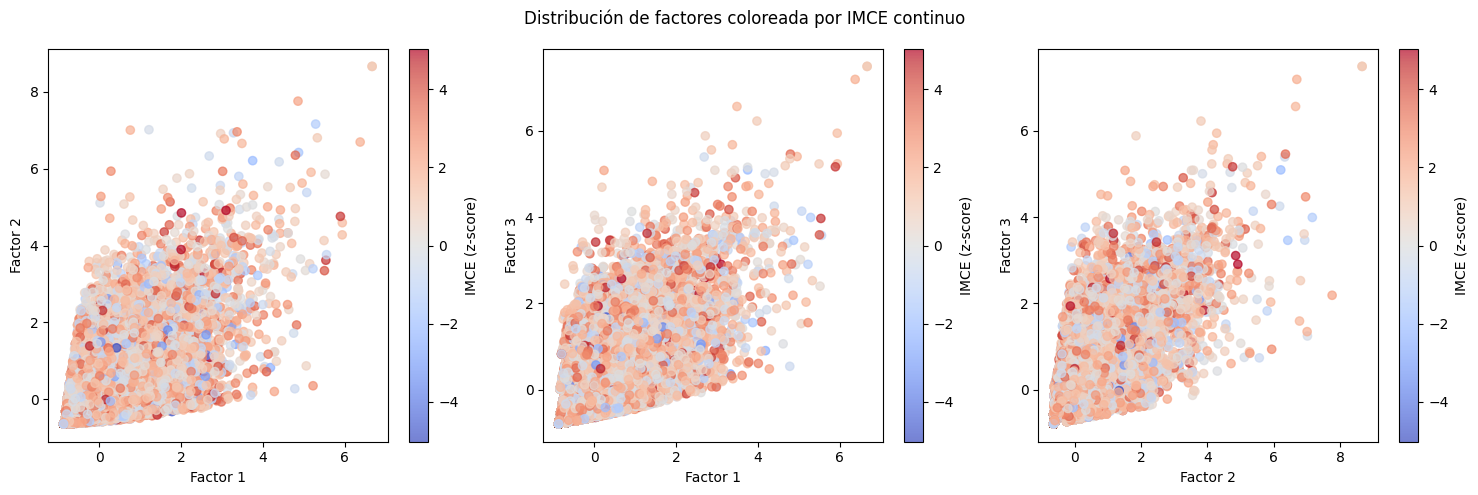

In [21]:
# Graficar pares de factores coloreando por imce 
df_factores['imce_cat'] = pd.qcut(df_factores['imce'], 3, labels=['Bajo', 'Medio', 'Alto'])
sns.pairplot(df_factores, vars=['Factor 1', 'Factor 2', 'Factor 3'], hue='imce_cat', palette='coolwarm')
plt.suptitle('Distribución de factores según IMCE', y=1.02)
plt.show()

# Scatterplot de pares de factores coloreando por IMCE continuo
plt.figure(figsize=(15, 5))
for i, (x, y) in enumerate([('Factor 1', 'Factor 2'), ('Factor 1', 'Factor 3'), ('Factor 2', 'Factor 3')]):
    plt.subplot(1, 3, i+1)
    sc = plt.scatter(df_factores[x], df_factores[y], c=df_factores['imce'], cmap='coolwarm', alpha=0.7)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.colorbar(sc, label='IMCE (z-score)')
plt.suptitle('Distribución de factores coloreada por IMCE continuo')
plt.tight_layout()
plt.show()

<u> *Explicación distribución de factores según IMCE* </u>


 <font size="3">Primero, los intervalos están distribuidos de la siguiente manera:</font>


<small>

| Categoría | Rango           |
|-----------|-----------------|
| Bajo      | [-5.02, 0.42]   |
| Medio     | [0.42, 1.56]    |
| Alto      | [1.56, 5.04]    |

</small>


<font size="3">Los puntos de las tres categorías de IMCE (Bajo, Medio, Alto) están bastante mezclados en todos los pares de factores y no se observa una separación clara ni agrupamientos definidos entre las categorías de IMCE en ninguno de los factores.
Las distribuciones marginales (en la diagonal) también son similares entre las categorías, lo que indica que la variabilidad de los factores no depende fuertemente del nivel de IMCE.

Esto sugiere que los factores identificados en el análisis factorial no discriminan entre estudiantes con bajo, medio o alto IMCE. Por lo tanto, el IMCE no parece estar asociado de manera relevante con la estructura factorial encontrada en este análisis.</font>



4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). 

<font size="3">**Respuesta pregunta 4**</font>

<u> *Análisis CFA* </u>

<font size="3">Ahora se implementará un análisis factorial confirmatorio (CFA) donde cada variable se asocia a solo un factor, esto según el EFA de la pregunta anterior, donde encontramos 3 factores. En resumen, las variables se es así: </font>

<small>

| Factor                        | Variables asociadas                  |
|-------------------------------|--------------------------------------|
| Factor 1: Expresión Emocional | "sk9", "sk10", "sk11", "sk12", "sk13"|
| Factor 2: Habilidades Sociales| "sk1", "sk2", "sk3", "sk4"           |
| Factor 3: Interés Cognitivo   | "sk5", "sk6", "sk8"                  |

</small>

<font size="3">**Factor 1**</font> = <font size="3"> Este factor relaciona variables que implican el desarrollo de la curiosidad de los niño, como al atreverse a hacer preguntas a adultos, o al manifestar intereses por libros, entornos y expresiones artísticas, por lo que implica cómo el niño comienza a observar su alrededor y manifestar su curiosidad que le permite tener intereses. Es decir, reflejan comportamientos de exploración, interés, creatividad y búsqueda de información en el entorno. Así, la variable se llamará **"Apertura a la exploración"** </font>

<font size="3">**Factor 2**</font> = <font size="3"> Este factor tiene variables que van ligadas al nivel de capacidad del estudiante de poder expresar y demostrar afecto y sus emociones, esto porque muestra su nivel de afecto a sus padres, pares, y de si expresa sus sentimientos o usa gestos para mostrar lo que siente. Por lo que están claramente relacionadas con la expresión emocional y el afecto hacia otros. Así, la variable se llamará **"Expresión emocional-afectiva"** </font>

<font size="3">**Factor 3**</font> = <font size="3"> Este factor tiene variables que hablan sobre el nivel de relación del niño con los demás en base al "juego", que es la acción principal del desarrollo de los estudiantes menores a 8 años de edad y es donde empiezan a entender y forjar su forma de enfrentar situaciones donde otros niños o personas están involucrados, tiene que ver también con su nivel de introversión o extroversión en caso de si no le gusta jugar con otros o no participa en juegos grupales. Agrupa variables relacionadas con la interacción social a través del juego y la cooperación. La variable se llamará **"Sociabilidad Lúdica"** </font>

In [22]:
mod = """
# Definición de factores latentes
Apertura =~ sk9 + sk10 + sk11 + sk12 + sk13
Expresion =~ sk1 + sk2 + sk3 + sk4
Sociabilidad =~ sk5 + sk6 + sk8
"""

model= semopy.Model(mod);
out = model.fit(df_sk);
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 41
Params: 1.348 1.248 1.097 1.274 1.877 1.646 1.846 1.020 1.158 0.152 0.049 0.051 0.161 0.091 0.057 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.372 0.469 0.277


In [23]:
model.inspect(mode='list', what="names", std_est=True)


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,Apertura,1.000000,0.594425,-,-,-
1,sk10,~,Apertura,1.348296,0.562596,0.01854,72.725071,0.0
2,sk11,~,Apertura,1.247906,0.736003,0.014736,84.684717,0.0
3,sk12,~,Apertura,1.097330,0.540702,0.015523,70.692694,0.0
4,sk13,~,Apertura,1.273586,0.506374,0.018913,67.339241,0.0
5,sk1,~,Expresion,1.000000,0.582652,-,-,-
6,sk2,~,Expresion,1.876642,0.644548,0.023793,78.87212,0.0
7,sk3,~,Expresion,1.646084,0.631816,0.021121,77.934883,0.0
8,sk4,~,Expresion,1.845637,0.715782,0.022169,83.253688,0.0
9,sk5,~,Sociabilidad,1.000000,0.718118,-,-,-


<u>Interpretación de las cargas factoriales (importancia de cada variable):</u>

<font size="3">Cada valor en la columna Estimate indica cuánto aporta cada variable al factor correspondiente. un valor cercano a 1 significa que está muy relacionada con su factor.</font>

<u>Conclusión:</u>

<font size="3">Todas las variables tienen su mayor carga en el factor esperado, lo que valida la estructura propuesta.</font>


<u>Interpretación de la correlación entre factores:</u>

<font size="3">Los valores de correlación (Estimate) entre los factores son 0.0, lo que indica que los factores latentes ("Apertura", "Expresion", "Sociabilidad") son independientes entre sí en este modelo. Es decir, el desarrollo de uno de estos aspectos no está relacionado estadísticamente con los otros factores en la muestra analizada. Por lo que se pudo haber usado tanto como promax como varimax.</font>

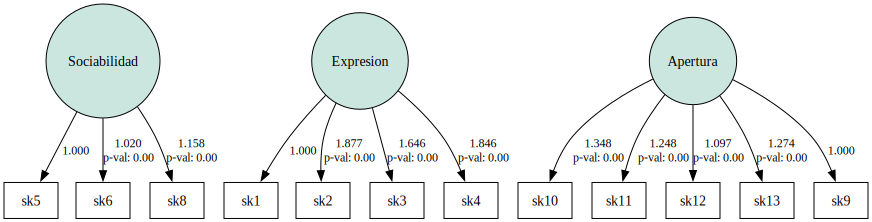

In [24]:
semopy.calc_stats(model)
semopy.semplot(model, "Junaeb3.png")

<u>CONCLUSIONES FINALES MODELO CFA</u>

<font size="3">El gráfico muestra la estructura factorial confirmatoria (CFA) propuesta, donde cada factor latente agrupa un conjunto específico de variables observadas:</font>

-Sociabilidad: agrupa las variables sk5, sk6 y sk8, relacionadas con la interacción social y el juego en grupo.

-Expresión: agrupa sk1, sk2, sk3 y sk4, que reflejan la capacidad de expresar emociones y afecto.

-Apertura: agrupa sk9, sk10, sk11, sk12 y sk13, asociadas a la curiosidad, creatividad e interés por el entorno.

<font size="3">Las cargas factoriales (números sobre las flechas) indican la fuerza de la relación entre cada variable y su factor. Todas las cargas son altas y estadísticamente significativas (p-valor = 0.00), lo que evidencia que las variables seleccionadas representan adecuadamente a cada factor.</font>

<font size="3">Además, cada variable solo se asocia a un factor, cumpliendo con el criterio de un modelo CFA simple y facilitando la interpretación. La independencia entre factores también se observa en los resultados numéricos.</font>



5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  2.84it/s, max_LL=-1.2e+6, max_avg_LL=-40.3]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.76it/s, max_LL=-1.08e+6, max_avg_LL=-36.4]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:10<00:00, 10.24s/it, max_LL=-9.88e+5, max_avg_LL=-33.3]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:06<00:00,  6.53s/it, max_LL=-9.96e+5, max_avg_LL=-33.5]


<Axes: >

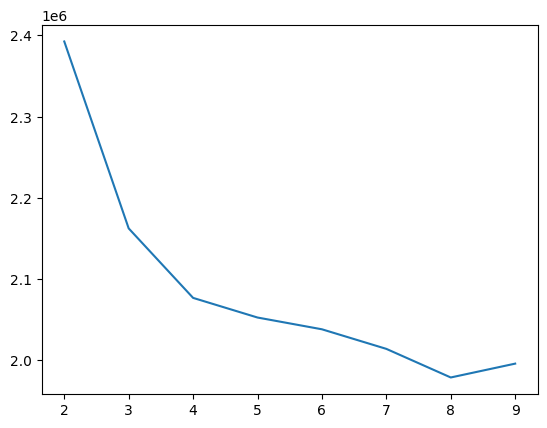

In [25]:
from stepmix.stepmix import StepMix
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Numero optimo de clusters
K = range(2, 10)
fits = []
BIC = []

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df2)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(df2))

sns.lineplot(x = K, y = BIC)    

<u>Gráfico para mejor interpretación</u>

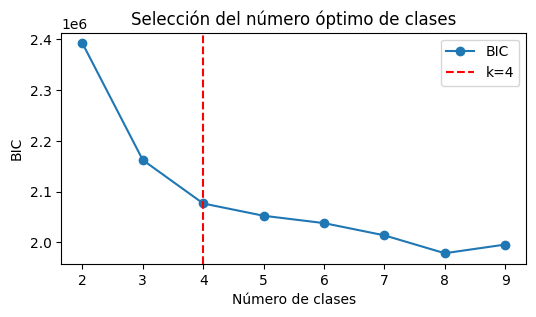

In [26]:
plt.figure(figsize=(6, 3))
plt.plot(K, BIC, marker='o', label='BIC')
plt.xlabel('Número de clases')
plt.ylabel('BIC')
plt.legend()
plt.title('Selección del número óptimo de clases')
plt.axvline(x=4, color='red', linestyle='--', label='k=4')
plt.legend()
plt.show()

<u>Interpretación Gráfico de número óptimo de clases</u>

<font size="3">El gráfico muestra que la línea empieza a reducir su inclinación (codo) cuando llega al número tres, esto significa que el número óptimo de clases según el análisis son tres. Sin embargo, el número óptimo podría ser también 3, ya que hay una brecha algo difusa entre cuando esta el codo, así que se empezará con los dos</font>


In [27]:
dfimc=df2[['imce']]
from stepmix.stepmix import StepMix
model = StepMix(n_components=4, measurement="gaussian_diag", verbose=1, random_state=123).fit(dfimc)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:07<00:00,  7.35s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name           gaussian_diag                        
          class_no                         0       1       2       3
          param       variable                                      
          covariances imce            1.5910  2.7312  1.5206  0.9168
          means       imce            1.5809 -0.1388  1.7591  0.4413
    Class weights
        Class 1 : 0.25
        Class 2 : 0.09
        Class 3 : 0.26
        Class 4 : 0.40
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 4
    Number of estimated parameters: 11
    Log-likelihood (LL)           : -51341.1384
    -2LL                          : 102682.2768
    Average LL                    : -1.7289
    AIC                           : 102704.28
    BIC                           : 102795.56
    CAIC                          : 102806.56
    Sample-Size Adjusted BIC  


c:\Users\darmo\AppData\Local\Programs\Python\Python313\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


In [ ]:
# Ahora con 3 componentes 
dfmix = df2
model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)

# Fit model and predict clusters
model.fit(dfimc)
dfmix['pred']=model.predict(dfimc)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.18s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            -1.949  2.4056  0.5984
    Class weights
        Class 1 : 0.02
        Class 2 : 0.27
        Class 3 : 0.71
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -51364.3251
    -2LL                          : 102728.6503
    Average LL                    : -1.7297
    AIC                           : 102738.65
    BIC                           : 102780.14
    CAIC                          : 102785.14
    Sample-Size Adjusted BIC      : 102815.75
    Entropy                       : 11499.4902
    Scaled Relative Entropy       : 0.6475


<small>

<u>**Comparación y cual elegir**</u>

Primero comparamos el tamaño de los BIC y Entropía relativa:

- **Clausters:3**
    - Bic = 102780
    - Entropía relativa = 0.6475
 
- **Clausters:4**
    - Bic = 102795
    - Entropía relativa = 0.2016

Comparando los BIC y las entropías relativas, el mejor modelo es el que tiene BIC menor, es decir 3 clausters.

<u>**Interpretación resultados del modelo StepMix con 3 clases latentes usando IMCE**</u>

**1. Parámetros del modelo (Measurement model parameters)**

- **Clases latentes:** El modelo encontró 3 grupos (clases) en los datos.
- **Medias (`means`) de IMCE por clase:**
  - **Clase 1:** 0.5012
  - **Clase 2:** 1.8813
  - **Clase 3:** -0.0576  
  Esto indica que la **Clase 2** tiene el IMCE promedio más alto, la **Clase 3** el más bajo, y la **Clase 1** está cerca de la media general.
- **Varianzas (`covariances`) de IMCE por clase:**
  - Indican la dispersión del IMCE dentro de cada clase. Clase 3 es la más dispersa.

**2. Pesos de clase (Class weights)**

- **Clase 1:** 49% de los estudiantes
- **Clase 2:** 41%
- **Clase 3:** 10%  
  La mayoría de los estudiantes están en las clases 1 y 2, y solo el 10% en la clase 3.

**3. Ajuste del modelo (Fit)**

- **Número de observaciones:** 29,696 estudiantes
- **Número de parámetros estimados:** 8
- **Entropía relativa escalada:** 0.3247  
  Valores cercanos a 1 indican mejor separación entre clases; aquí es bajo, lo que sugiere que las clases no están perfectamente separadas.

**4. Advertencia de convergencia**

El modelo muestra una advertencia de que **no todas las inicializaciones convergieron**.  
Esto puede deberse a datos difíciles de separar o a que se necesitan más iteraciones.

</small>


In [29]:
# Mapeamos las clases a etiquetas 
dfmix['pred'] = dfmix['pred'].map({0: 'Clase 1', 1: 'Clase 2', 2: 'Clase 3'})   

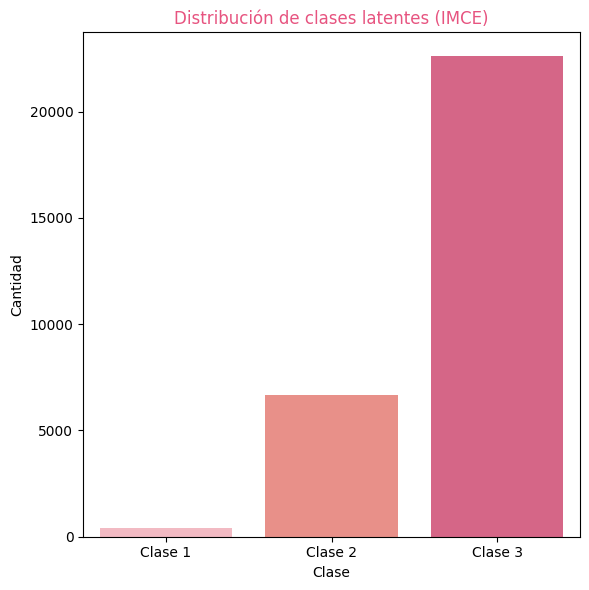

In [30]:
# Visualización de la distribución de las clases latentes en tonos rosados
plt.figure(figsize=(6,6))
sns.countplot(
    data=dfmix, 
    x='pred', 
    order=['Clase 1', 'Clase 2', 'Clase 3'],
    palette=['#fbb1bd', '#f88379', '#e75480']  # Tonos rosados
)
plt.title('Distribución de clases latentes (IMCE)', fontsize=12, color='#e75480')
plt.xlabel('Clase', fontsize=10)
plt.ylabel('Cantidad', fontsize=10)
plt.tight_layout()
plt.show()

<u> Conclusión final</u>

<small>

- El único atributo que realmente diferencia a los grupos (clusters) es el IMCE (índice de masa corporal estandarizado), ya que fue la única variable usada para crear los clusters.

- Cluster 1: Agrupa a los niños con IMCE más alto (por sobre la media).

- Cluster 2: Agrupa a los niños con IMCE más bajo (por debajo de la media).

- Cluster 3: Agrupa a los niños cuyo IMCE está cerca del promedio (alrededor de la media).

La variable IMCE es la que define y diferencia a los clusters, y cada cluster representa un rango distinto de IMCE (alto, bajo y promedio). No hay otras variables que distingan a los grupos, porque solo IMCE fue usada para la agrupación.

<small>

6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

In [ ]:
#Especifiación del modelo SEM completo
mod_completo = """
# measurement model
Apertura =~ sk9 + sk10 + sk11 + sk12 + sk13
Expresion =~ sk1 + sk2 + sk3 + sk4
Sociabilidad =~ sk5 + sk6 + sk8

# structural model
imce ~ Apertura + Expresion + Sociabilidad + sexo + area + act_fisica + madre_work + vive_padre + vive_madre + sk7
"""

In [ ]:
# Ajustar el modelo SEM incluyendo las demás variables de la data inicial.
model = semopy.Model(mod_completo)
model.fit(df2)

SolverResult(fun=np.float64(0.3564153166136137), success=np.True_, n_it=51, x=array([1.347449, 1.246960, 1.096472, 1.272536, 1.879342, 1.646930,
       1.848047, 1.019737, 1.159893, -0.028238, -0.307033, 0.226416,
       0.127955, -0.169268, -0.025727, 0.029616, -0.015112, -0.041464,
       -0.028394, 0.151792, 0.048721, 0.051222, 0.160573, 0.091079,
       0.057251, 1.861427, 0.095005, 0.595159, 0.199818, 0.441929,
       0.713308, 0.241833, 0.199136, 0.158216, 0.150953, 0.372592,
       0.469117, 0.277422]), message='Optimization terminated successfully', name_method='SLSQP', name_obj='MLW')

In [35]:
# Inspeccionar los parámetros estandarizados
params = model.inspect(std_est=True)
display(params)


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,Apertura,1.000000,0.594686,-,-,-
1,sk10,~,Apertura,1.347449,0.562586,0.018524,72.74201,0.0
2,sk11,~,Apertura,1.246960,0.735891,0.014721,84.70746,0.0
3,sk12,~,Apertura,1.096472,0.540609,0.015509,70.70027,0.0
4,sk13,~,Apertura,1.272536,0.506244,0.018897,67.340237,0.0
5,sk1,~,Expresion,1.000000,0.582226,-,-,-
6,sk2,~,Expresion,1.879342,0.644779,0.023834,78.849767,0.0
7,sk3,~,Expresion,1.646930,0.631586,0.021147,77.879951,0.0
8,sk4,~,Expresion,1.848047,0.715962,0.022207,83.217729,0.0
9,sk5,~,Sociabilidad,1.000000,0.717941,-,-,-


In [36]:
# Índices de ajuste
fit_stats = semopy.calc_stats(model)
print(fit_stats[['TLI', 'CFI', 'RMSEA']])

            TLI       CFI     RMSEA
Value  0.866683  0.883602  0.045151


<u> Interpretación de índices de modelo SEM</u>

<small>

El modelo SEM presenta un ajuste aceptable a bueno. El RMSEA indica un ajuste excelente, mientras que TLI y CFI muestran que el modelo es razonable, aunque podría mejorarse ligeramente para alcanzar el estándar de “buen ajuste” (≥0.90). En general, puedes considerar que tu modelo es adecuado para interpretar los resultados.

<small>

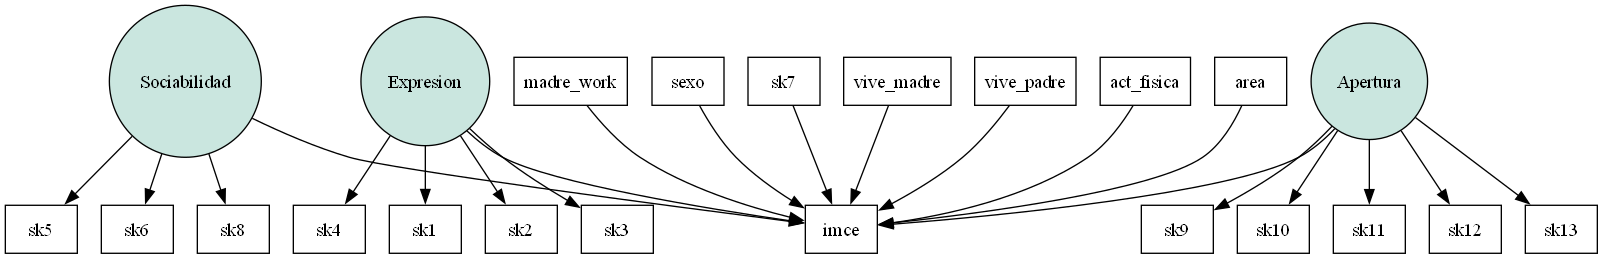

In [ ]:
# Visualización de la estructura del modelo SEM
semopy.semplot(mod_completo, "sem_model.png")
from IPython.display import Image
Image("sem_model.png")

7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?  

In [39]:
resultados = {}

# Ajustar el modelo para cada clase latente
for clase in dfmix['pred'].unique():
    print(f"\nResultados para {clase}:")
    df_sub = dfmix[dfmix['pred'] == clase]
    model = semopy.Model(mod_completo)  
    model.fit(df_sub)
    est = model.inspect(std_est=True)
    stats = semopy.calc_stats(model)
    print(stats[['TLI', 'CFI', 'RMSEA']])
    display(est)
    resultados[clase] = {'params': est, 'fit': stats[['TLI', 'CFI', 'RMSEA']]}



Resultados para Clase 3:
            TLI       CFI     RMSEA
Value  0.867458  0.884278  0.044925


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,Apertura,1.000000,0.590701,-,-,-
1,sk10,~,Apertura,1.345811,0.562028,0.021323,63.11423,0.0
2,sk11,~,Apertura,1.252098,0.737811,0.017043,73.46762,0.0
3,sk12,~,Apertura,1.088928,0.537739,0.017803,61.165587,0.0
4,sk13,~,Apertura,1.247476,0.498227,0.021581,57.805271,0.0
5,sk1,~,Expresion,1.000000,0.575842,-,-,-
6,sk2,~,Expresion,1.890051,0.640700,0.027757,68.091788,0.0
7,sk3,~,Expresion,1.691475,0.639450,0.02487,68.013496,0.0
8,sk4,~,Expresion,1.898629,0.719663,0.026277,72.254546,0.0
9,sk5,~,Sociabilidad,1.000000,0.714364,-,-,-



Resultados para Clase 2:
            TLI       CFI    RMSEA
Value  0.862939  0.880332  0.04609


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,Apertura,1.000000,0.603618,-,-,-
1,sk10,~,Apertura,1.364015,0.563521,0.039045,34.934067,0.0
2,sk11,~,Apertura,1.242872,0.730783,0.030517,40.726764,0.0
3,sk12,~,Apertura,1.142840,0.550702,0.033264,34.357015,0.0
4,sk13,~,Apertura,1.359700,0.529689,0.040732,33.381922,0.0
5,sk1,~,Expresion,1.000000,0.610706,-,-,-
6,sk2,~,Expresion,1.805981,0.657311,0.046353,38.961481,0.0
7,sk3,~,Expresion,1.481094,0.606440,0.040024,37.005459,0.0
8,sk4,~,Expresion,1.646546,0.701244,0.040809,40.347302,0.0
9,sk5,~,Sociabilidad,1.000000,0.728584,-,-,-



Resultados para Clase 1:
            TLI       CFI     RMSEA
Value  0.862425  0.879883  0.047144


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,Apertura,1.000000,0.668034,-,-,-
1,sk10,~,Apertura,1.045602,0.522207,0.11959,8.743214,0.0
2,sk11,~,Apertura,1.111266,0.749830,0.098758,11.252433,0.0
3,sk12,~,Apertura,0.825027,0.552013,0.090079,9.158886,0.0
4,sk13,~,Apertura,1.073116,0.503715,0.126572,8.478305,0.0
5,sk1,~,Expresion,1.000000,0.505875,-,-,-
6,sk2,~,Expresion,2.465915,0.641884,0.289132,8.528692,0.0
7,sk3,~,Expresion,2.202636,0.636288,0.259414,8.490828,0.0
8,sk4,~,Expresion,2.775494,0.779009,0.301331,9.210772,0.0
9,sk5,~,Sociabilidad,1.000000,0.690185,-,-,-


<u> Interpretación</u>

<small>

| Clase    | TLI    | CFI    | RMSEA  |
|----------|--------|--------|--------|
| Clase 1  | 0.862  | 0.880  | 0.047  |
| Clase 2  | 0.863  | 0.880  | 0.046  |
| Clase 3  | 0.867  | 0.884  | 0.045  |

- **TLI y CFI:**
En todas las clases, los valores de TLI y CFI están entre 0.86 y 0.88. Esto indica un ajuste aceptable, aunque no excelente (el estándar de “buen ajuste” suele ser ≥0.90). Los modelos funcionan de manera similar en los tres grupos, sin diferencias relevantes.

- **RMSEA:**
Los valores de RMSEA son bajos en todas las clases (entre 0.044 y 0.047), lo que indica un muy buen ajuste del modelo en cada subgrupo (valores <0.05 se consideran excelentes).

<u> Conclusión general </u>

- El modelo SEM se ajusta de forma similar y aceptable en los tres grupos latentes definidos por IMCE.

- No hay diferencias importantes entre los grupos en cuanto a los índices de ajuste.

- El RMSEA muestra que el modelo representa bien los datos en todos los subgrupos.

- No se observa una ganancia clara de estimar el modelo por grupos en términos de ajuste global, ya que los resultados son muy parecidos entre clases.

**En resumen:**
El modelo SEM es robusto y consistente en todos los subgrupos, pero no mejora sustancialmente el ajuste al estimar por separado para cada clase latente.

<small>

Diagrama SEM para Clase 3:


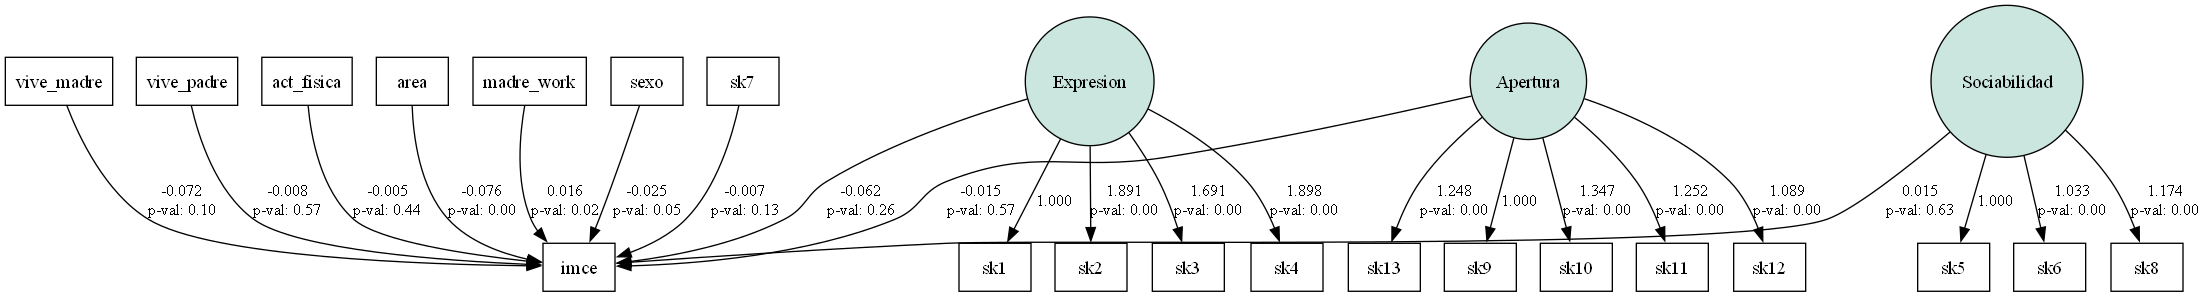

Diagrama SEM para Clase 2:


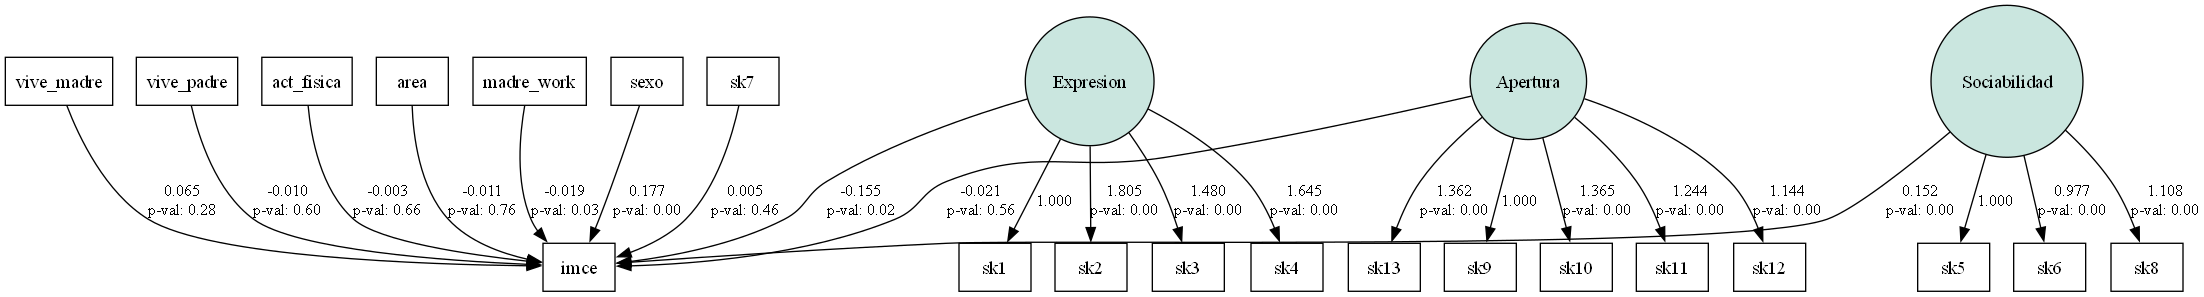

Diagrama SEM para Clase 1:


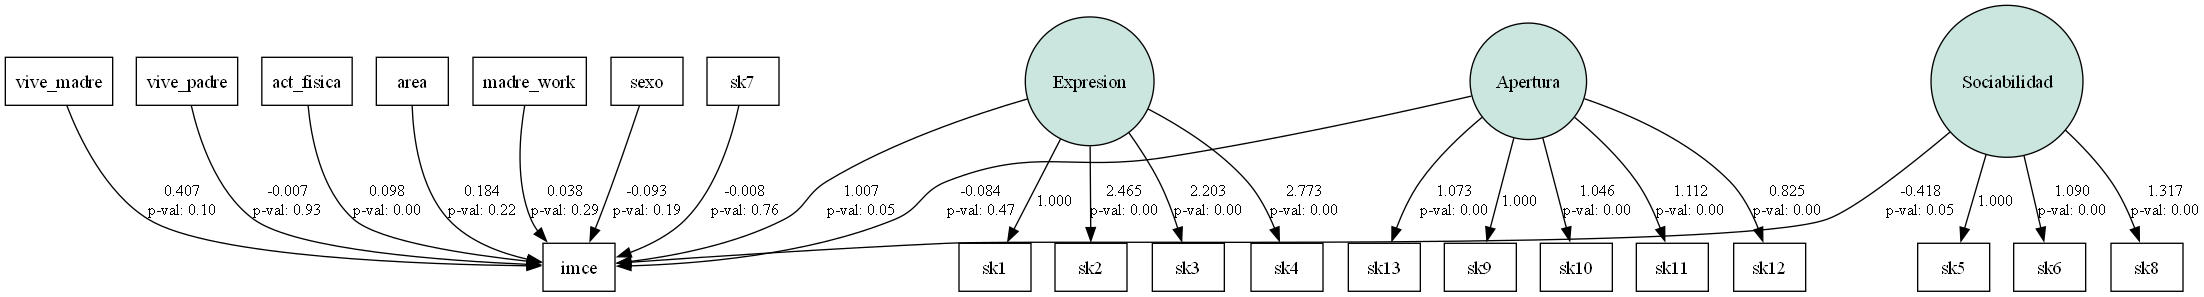

In [40]:
from IPython.display import Image

for clase in dfmix['pred'].unique():
    print(f"Diagrama SEM para {clase}:")
    df_sub = dfmix[dfmix['pred'] == clase]
    model.fit(df_sub)
    filename = f"sem_model_{clase}.png"
    semopy.semplot(model, filename)
    display(Image(filename))
    